# Castrophic Forgetting - Nueral Network Memory Net 

In [1]:
# Import Libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import copy

In [2]:
#Cuda Device
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f'Device name:{device}')

Device name:cpu


In [3]:
#Load Datasets
dataset_a = pd.read_csv('../data/spilts/dataset_a.csv')
dataset_b = pd.read_csv('../data/spilts/dataset_b.csv')

print(f'Dataset A:{dataset_a.shape}')
print(f'Dataset B:{dataset_b.shape}')

Dataset A:(2697, 9)
Dataset B:(2533, 9)


In [4]:
#Define Features and Target
Features = ['compound_encoded', 'TyreLife', 'tyre_life_norm', 
            'LapNumber', 'lapnumber_norm', 'StintNumber']
Target = 'LapTimeSeconds'

In [5]:
#Rebuilding Data pipeline
clean_a = dataset_a[Features + [Target]].dropna().reset_index(drop=True)
clean_b = dataset_b[Features + [Target]].dropna().reset_index(drop=True)

scaler = StandardScaler()
X_a = scaler.fit_transform(clean_a[Features].values)
y_a = clean_a[Target].values

X_b = scaler.transform(clean_b[Features].values)
y_b = clean_b[Target].values

# tensors
X_a_tensor = torch.FloatTensor(X_a)
y_a_tensor = torch.FloatTensor(y_a).reshape(-1, 1)
X_b_tensor = torch.FloatTensor(X_b)
y_b_tensor = torch.FloatTensor(y_b).reshape(-1, 1)

# dataloaders
loader_a = DataLoader(TensorDataset(X_a_tensor, y_a_tensor), batch_size=64, shuffle=True)
loader_b = DataLoader(TensorDataset(X_b_tensor, y_b_tensor), batch_size=64, shuffle=True)

In [6]:
#Loading Previous Tranied Model
class LapTimeNet(nn.Module):
    def __init__(self, input_size):
        super(LapTimeNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# load your saved model from phase 3
model = LapTimeNet(input_size=len(Features))
model.load_state_dict(torch.load('../outputs/models/model_after_A.pt'))
model = model.to(device)
print("Model loaded successfully")

Model loaded successfully


In [7]:
#Eval Model
def evaluate_model(model, X_tensor, y_true):
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor.to(device)).cpu().numpy().flatten()
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    return mae, rmse, predictions

In [8]:
#Confirming Baseline Numbers - MAE
mae_a_baseline, rmse_a_baseline, _ = evaluate_model(model, X_a_tensor, y_a)
mae_b_baseline, rmse_b_baseline, _ = evaluate_model(model, X_b_tensor, y_b)

print(f"Dataset A baseline — MAE: {mae_a_baseline:.3f}s")
print(f"Dataset B baseline — MAE: {mae_b_baseline:.3f}s")

Dataset A baseline — MAE: 5.176s
Dataset B baseline — MAE: 5.958s


In [9]:
# Saving Deep Copy before Fine tune
model_before_finetune = copy.deepcopy(model)
print('Original model saved')

Original model saved


In [10]:
#Fine tuning with no protection
def finetune_model(model, loader, epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    loss_history = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")
    
    return loss_history

print("Fine-tuning on Dataset B with no protection...")
loss_history_b = finetune_model(model, loader_b, epochs=50)

Fine-tuning on Dataset B with no protection...
Epoch 10/50 — Loss: 150.2149
Epoch 20/50 — Loss: 142.8464
Epoch 30/50 — Loss: 150.4568
Epoch 40/50 — Loss: 140.3222
Epoch 50/50 — Loss: 148.0905


In [11]:
#Eval
mae_a_after, rmse_a_after, preds_a_after = evaluate_model(model, X_a_tensor, y_a)
mae_b_after, rmse_b_after, preds_b_after = evaluate_model(model, X_b_tensor, y_b)

print(f"Dataset A after fine-tuning — MAE: {mae_a_after:.3f}s")
print(f"Dataset B after fine-tuning — MAE: {mae_b_after:.3f}s")

print(f"\nDataset A degradation: {mae_a_after - mae_a_baseline:.3f}s")
print(f"Dataset B improvement: {mae_b_baseline - mae_b_after:.3f}s")

Dataset A after fine-tuning — MAE: 5.496s
Dataset B after fine-tuning — MAE: 3.965s

Dataset A degradation: 0.320s
Dataset B improvement: 1.993s


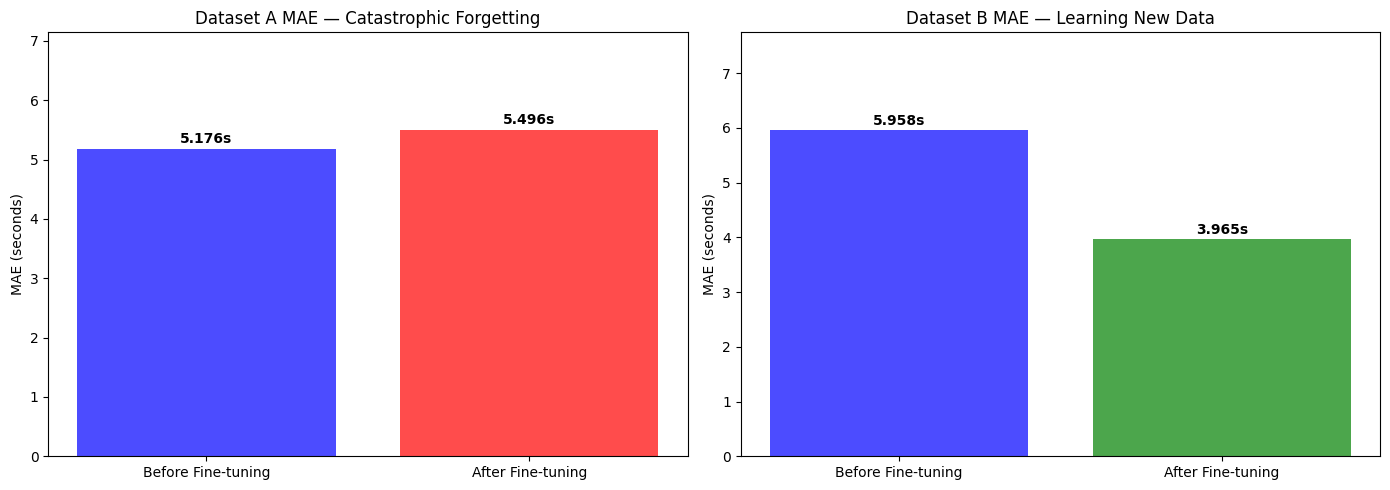

In [12]:
#viz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset A comparison
categories = ['Before Fine-tuning', 'After Fine-tuning']
mae_a_values = [mae_a_baseline, mae_a_after]
mae_b_values = [mae_b_baseline, mae_b_after]

axes[0].bar(categories, mae_a_values, color=['blue', 'red'], alpha=0.7)
axes[0].set_title('Dataset A MAE — Catastrophic Forgetting', fontsize=12)
axes[0].set_ylabel('MAE (seconds)')
axes[0].set_ylim(0, max(mae_a_values) * 1.3)
for i, v in enumerate(mae_a_values):
    axes[0].text(i, v + 0.1, f'{v:.3f}s', ha='center', fontweight='bold')

# Dataset B comparison
axes[1].bar(categories, mae_b_values, color=['blue', 'green'], alpha=0.7)
axes[1].set_title('Dataset B MAE — Learning New Data', fontsize=12)
axes[1].set_ylabel('MAE (seconds)')
axes[1].set_ylim(0, max(mae_b_values) * 1.3)
for i, v in enumerate(mae_b_values):
    axes[1].text(i, v + 0.1, f'{v:.3f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/catastrophic_forgetting.png')
plt.show()

In [14]:
print("Weight changes per layer after fine-tuning:\n")
for (name_before, param_before), (name_after, param_after) in zip(
    model_before_finetune.named_parameters(), 
    model.named_parameters()
):
    change = (param_after.data.cpu() - param_before.data.cpu()).abs().mean().item()
    print(f"{name_after}: avg weight change = {change:.6f}")

Weight changes per layer after fine-tuning:

network.0.weight: avg weight change = 0.064365
network.0.bias: avg weight change = 0.044484
network.3.weight: avg weight change = 0.017413
network.3.bias: avg weight change = 0.155749
network.6.weight: avg weight change = 0.028302
network.6.bias: avg weight change = 1.333734
